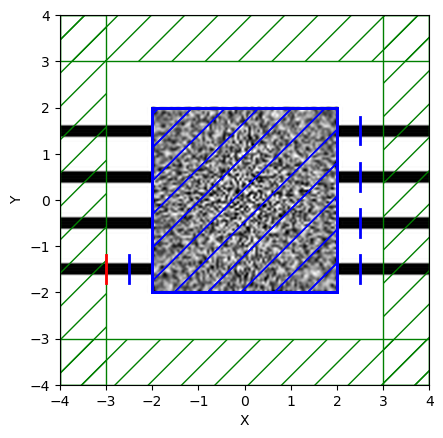

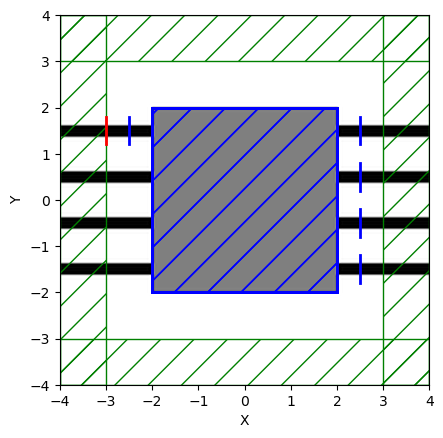

In [ ]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 20

# cell size
Sx = 8
Sy = 8
cell_size = mp.Vector3(Sx, Sy)
pml_layers = [mp.PML(1.0)]

# source
port_ys = [1.5, 0.5, -0.5, -1.5]

lambda_list = np.array([1.55, 1.56, 1.57, 1.58])
freq_list = 1 / lambda_list

width = 0.6
source_size = mp.Vector3(0, 0.6, 0)

source_x = -3

target_matrix = np.array([
    [1/4, 1/4, 1/4, 1/4],
    [0,   1/3, 1/3, 1/3],
    [0,   0,   1/2, 1/2],
    [0,   0,   0,   1  ],
])


def make_source(case_idx):
    """
    case_idx = 0: port 1 input, lambda = 1.55 um
    case_idx = 1: port 2 input, lambda = 1.56 um
    case_idx = 2: port 3 input, lambda = 1.57 um
    case_idx = 3: port 4 input, lambda = 1.58 um
    """

    fcen_case = freq_list[case_idx]
    fwidth_case = width * fcen_case

    src = mp.GaussianSource(
        frequency=fcen_case,
        fwidth=fwidth_case
    )

    source = [
        mp.EigenModeSource(
            src,
            eig_band=1,
            eig_match_freq=True,
            direction=mp.X,
            size=source_size,
            center=mp.Vector3(source_x, port_ys[case_idx], 0),
        )
    ]

    return source

#design region
Dx = 4
Dy = 4
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution) + 1
Ny = int(Dy * design_region_resolution) + 1

design_variables = mp.MaterialGrid(mp.Vector3(Nx,Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))

# geometry
wg_width = 0.25

wg_length = (Sx - Dx) / 2

x_in = -Dx/2 - wg_length/2
x_out = Dx/2 + wg_length/2

geometry = []

# input / output waveguides
for y in port_ys:
    # input waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

    # output waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# OSU design region
geometry.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=design_variables
    )
)

# FOM
def make_J(case_idx):

    target = npa.array(target_matrix[case_idx])
    target_norm = npa.mean(target ** 2) + 1e-12

    def J(a_in, a1, a2, a3, a4):
        Pin = npa.squeeze(npa.abs(a_in) ** 2) + 1e-12

        powers = npa.array([
            npa.squeeze(npa.abs(a1) ** 2),
            npa.squeeze(npa.abs(a2) ** 2),
            npa.squeeze(npa.abs(a3) ** 2),
            npa.squeeze(npa.abs(a4) ** 2)
        ])

        T = powers / Pin

        mse = npa.mean((T - target) ** 2)

        fom = 1 - mse / target_norm

        return fom

    return J


opt_list = []

for case_idx in range(4):

    fcen = freq_list[case_idx]
    source = make_source(case_idx)

    sim = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        eps_averaging=False,
        resolution=resolution,
    )

    # input monitor
    TE_in = mpa.EigenmodeCoefficient(
        sim,
        mp.Volume(
            center=mp.Vector3(-2.5, port_ys[case_idx], 0),
            size=mp.Vector3(y=0.6)
        ),
        mode=1,
        forward=True
    )

    # output monitors
    TE_out = []

    for y in port_ys:
        TE_out.append(
            mpa.EigenmodeCoefficient(
                sim,
                mp.Volume(
                    center=mp.Vector3(2.5, y, 0),
                    size=mp.Vector3(y=0.6)
                ),
                mode=1
            )
        )

    ob_list = [TE_in] + TE_out

    J_case = make_J(case_idx)

    opt = mpa.OptimizationProblem(
        simulation=sim,
        objective_functions=J_case,
        objective_arguments=ob_list,
        design_regions=[design_region],
        fcen=fcen,
        df=0,
        nf=1,
    )

    opt_list.append(opt)

x0 = np.random.rand(Nx * Ny)
opt.update_design([x0])

opt.plot2D(True, frequency=1 / 1.55)
plt.show()

x0 = 0.5 * np.ones((Nx * Ny,))

for opt_case in opt_list:
    opt_case.update_design([x0])

opt_list[0].plot2D(True, frequency=freq_list[0])
plt.show()


In [4]:
evaluation_history = []
case_history = []
cur_iter = [0]

num_design_variables = Nx * Ny
num_cases = len(opt_list)

case_weights = np.ones(num_cases) / num_cases


def get_gradient_array(dJ_du):
    g = dJ_du

    while isinstance(g, (list, tuple)):
        g = g[0]

    g = np.real(np.squeeze(np.asarray(g)))
    g = g.reshape(-1)

    return g


def f(v, gradient):
    cur_iter[0] += 1

    total_fom = 0.0
    total_grad = np.zeros(num_design_variables)

    case_foms = []
    for case_idx, opt_case in enumerate(opt_list):

        fom_i, dJ_du_i = opt_case([v], need_gradient=True)

        fom_i = float(np.real(np.squeeze(fom_i)))
        g_i = get_gradient_array(dJ_du_i)

        if g_i.size != num_design_variables:
            raise ValueError(
                f"Gradient size mismatch at case {case_idx}: "
                f"got {g_i.size}, expected {num_design_variables}"
            )

        w = case_weights[case_idx]

        total_fom += w * fom_i
        total_grad += w * g_i

        case_foms.append(fom_i)

    if gradient.size > 0:
        gradient[:] = total_grad

    evaluation_history.append(total_fom)
    case_history.append(case_foms)

    print(
        f"iter {cur_iter[0]:03d} | "
        f"FOM = {total_fom:.8f} | "
        f"cases = [{case_foms[0]:.4f}, {case_foms[1]:.4f}, "
        f"{case_foms[2]:.4f}, {case_foms[3]:.4f}]"
    )

    return total_fom


algorithm = nlopt.LD_MMA
solver = nlopt.opt(algorithm, Nx * Ny)

solver.set_lower_bounds(np.zeros(Nx * Ny))
solver.set_upper_bounds(np.ones(Nx * Ny))

solver.set_max_objective(f)

solver.set_maxeval(5)
solver.set_ftol_rel(1e-5)

x = solver.optimize(x0)

x = np.clip(x, 0.0, 1.0)


for opt_case in opt_list:
    opt_case.update_design([x])


Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


...

Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 005 | FOM = 0.56456205 | cases = [0.5952, 0.4368, 0.3530, 0.8733]


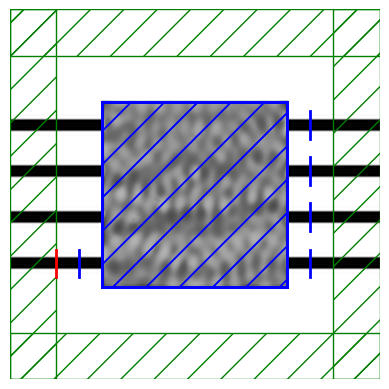

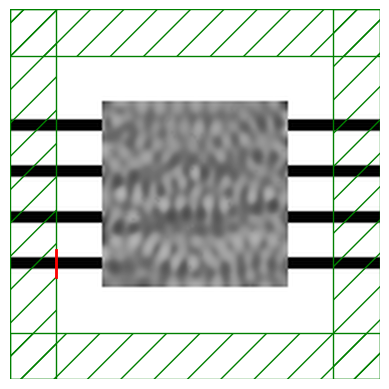

In [5]:
opt.update_design([x])
opt.plot2D(
    True,
    plot_monitors_flag=False,
    output_plane=mp.Volume(center=(0,0,0), size=(8,8,0))
)
plt.axis("off")

opt.update_design([x])

plt.figure()
sim.plot2D(
    output_plane=mp.Volume(center=mp.Vector3(), size=mp.Vector3(8,8,0)),
    labels=False
)
plt.axis("off")
plt.show()

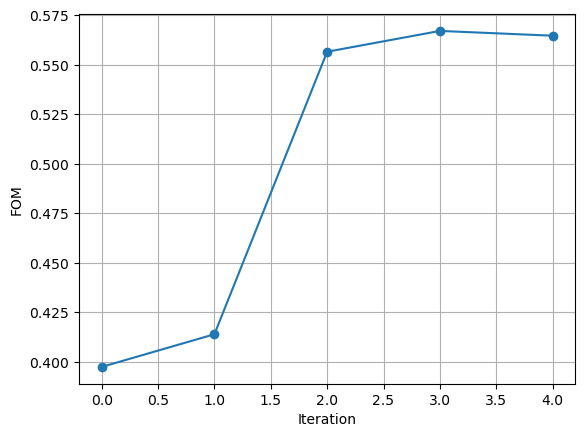

In [6]:
plt.figure()
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.show()

Case index: 0
Input port: 1
Lambda: 1.55 um

Input flux: 5.710738809069302
Output flux 1: 1.4914110579101691
Output flux 2: 2.177125375013593
Output flux 3: 0.4132188279395455
Output flux 4: 0.15037289691009448

Transmission wrt input:
T1 = 0.2611590387467273
T2 = 0.38123357551497017
T3 = 0.07235820823801414
T4 = 0.02633160120565928

Transmission (%):
T1 = 26.115903874672732
T2 = 38.123357551497016
T3 = 7.235820823801414
T4 = 2.633160120565928

Target:
target 1 = 0.25
target 2 = 0.25
target 3 = 0.25
target 4 = 0.25


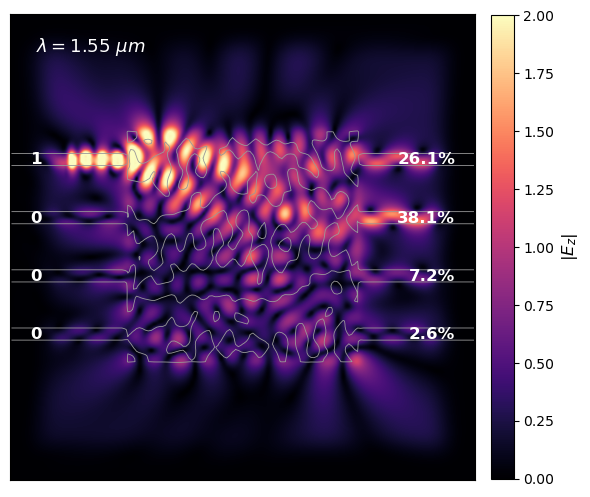

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import meep as mp

# =========================================
# 0. 보고 싶은 case 선택
# =========================================
# case_idx = 0 -> input port 1, lambda = 1.55 um, target = [1/4, 1/4, 1/4, 1/4]
# case_idx = 1 -> input port 2, lambda = 1.56 um, target = [0, 1/3, 1/3, 1/3]
# case_idx = 2 -> input port 3, lambda = 1.57 um, target = [0, 0, 1/2, 1/2]
# case_idx = 3 -> input port 4, lambda = 1.58 um, target = [0, 0, 0, 1]

case_idx = 0     # 여기만 0, 1, 2, 3으로 바꿔가면서 실행
design_to_plot = x  # 최적화 후면 x, 초기 구조면 x0

fcen_case = freq_list[case_idx]
lambda_case = lambda_list[case_idx]
input_y = port_ys[case_idx]
target_case = target_matrix[case_idx]

# =========================================
# 1. plot용 design variable 새로 생성
#    opt_list / sim_list 없이 현재 design만 반영
# =========================================
plot_design_variables = mp.MaterialGrid(
    mp.Vector3(Nx, Ny),
    mp.air,
    Si,
    weights=design_to_plot.reshape((Nx, Ny)),
    grid_type="U_MEAN"
)

# =========================================
# 2. plot용 geometry 새로 생성
# =========================================
geometry_plot = []

for y in port_ys:
    # input waveguide
    geometry_plot.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

    # output waveguide
    geometry_plot.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# optimized design region
geometry_plot.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=plot_design_variables
    )
)

# =========================================
# 3. 선택한 case의 source로 simulation 생성
# =========================================
source_case = make_source(case_idx)

sim_plot = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry_plot,
    sources=source_case,
    eps_averaging=False,
    resolution=resolution,
)

# =========================================
# 4. input / output flux monitor 추가
#    입력 기준 transmission 계산용
# =========================================
input_flux = sim_plot.add_flux(
    fcen_case, 0, 1,
    mp.FluxRegion(
        center=mp.Vector3(-2.5, input_y, 0),
        size=mp.Vector3(0, 0.6, 0)
    )
)

output_flux_1 = sim_plot.add_flux(
    fcen_case, 0, 1,
    mp.FluxRegion(
        center=mp.Vector3(2.5, port_ys[0], 0),
        size=mp.Vector3(0, 0.6, 0)
    )
)

output_flux_2 = sim_plot.add_flux(
    fcen_case, 0, 1,
    mp.FluxRegion(
        center=mp.Vector3(2.5, port_ys[1], 0),
        size=mp.Vector3(0, 0.6, 0)
    )
)

output_flux_3 = sim_plot.add_flux(
    fcen_case, 0, 1,
    mp.FluxRegion(
        center=mp.Vector3(2.5, port_ys[2], 0),
        size=mp.Vector3(0, 0.6, 0)
    )
)

output_flux_4 = sim_plot.add_flux(
    fcen_case, 0, 1,
    mp.FluxRegion(
        center=mp.Vector3(2.5, port_ys[3], 0),
        size=mp.Vector3(0, 0.6, 0)
    )
)

# =========================================
# 5. DFT field monitor 추가
#    배경 field intensity plot용
# =========================================
dft_fields = sim_plot.add_dft_fields(
    [mp.Ez],
    fcen_case,
    0,
    1,
    center=mp.Vector3(),
    size=cell_size
)

# =========================================
# 6. simulation run
# =========================================
sim_plot.run(
    until_after_sources=mp.stop_when_fields_decayed(
        50,
        mp.Ez,
        mp.Vector3(2.5, input_y, 0),
        1e-6
    )
)

# =========================================
# 7. field / dielectric 가져오기
# =========================================
ez_dft = sim_plot.get_dft_array(dft_fields, mp.Ez, 0)

eps_data = sim_plot.get_array(
    center=mp.Vector3(),
    size=cell_size,
    component=mp.Dielectric
)

# =========================================
# 8. field plot용 값
# =========================================
field_amp = np.abs(ez_dft)

# 보기 좋게 percentile 정규화
vref = np.percentile(field_amp, 99.5)
field_plot = field_amp / (vref + 1e-12) * 2.0
field_plot = np.clip(field_plot, 0, 2.0)

# =========================================
# 9. 입력 기준 transmission 계산
#    Ti = P_out_i / P_in
# =========================================
Pin = mp.get_fluxes(input_flux)[0]
Pin = max(Pin, 1e-12)

Pout1 = max(mp.get_fluxes(output_flux_1)[0], 0)
Pout2 = max(mp.get_fluxes(output_flux_2)[0], 0)
Pout3 = max(mp.get_fluxes(output_flux_3)[0], 0)
Pout4 = max(mp.get_fluxes(output_flux_4)[0], 0)

T1 = Pout1 / Pin
T2 = Pout2 / Pin
T3 = Pout3 / Pin
T4 = Pout4 / Pin

print(f"Case index: {case_idx}")
print(f"Input port: {case_idx + 1}")
print(f"Lambda: {lambda_case:.2f} um")
print()
print("Input flux:", Pin)
print("Output flux 1:", Pout1)
print("Output flux 2:", Pout2)
print("Output flux 3:", Pout3)
print("Output flux 4:", Pout4)
print()
print("Transmission wrt input:")
print("T1 =", T1)
print("T2 =", T2)
print("T3 =", T3)
print("T4 =", T4)
print()
print("Transmission (%):")
print("T1 =", 100 * T1)
print("T2 =", 100 * T2)
print("T3 =", 100 * T3)
print("T4 =", 100 * T4)
print()
print("Target:")
print("target 1 =", target_case[0])
print("target 2 =", target_case[1])
print("target 3 =", target_case[2])
print("target 4 =", target_case[3])

# =========================================
# 10. plot
# =========================================
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    field_plot.T,
    origin="lower",
    cmap="magma",
    extent=[-Sx/2, Sx/2, -Sy/2, Sy/2],
    interpolation="spline36",
    vmin=0,
    vmax=2.0
)

# 구조 윤곽선
eps_air = 1.0
eps_si = 3.4**2
eps_level = (eps_air + eps_si) / 2

ax.contour(
    eps_data.T,
    levels=[eps_level],
    colors="0.6",
    linewidths=0.6,
    origin="lower",
    extent=[-Sx/2, Sx/2, -Sy/2, Sy/2]
)

# =========================================
# 11. 왼쪽 input label
# =========================================
input_label_1 = "1" if case_idx == 0 else "0"
input_label_2 = "1" if case_idx == 1 else "0"
input_label_3 = "1" if case_idx == 2 else "0"
input_label_4 = "1" if case_idx == 3 else "0"

ax.text(
    -Sx/2 + 0.35,
    port_ys[0],
    input_label_1,
    color="white",
    fontsize=12,
    ha="left",
    va="center",
    weight="bold"
)

ax.text(
    -Sx/2 + 0.35,
    port_ys[1],
    input_label_2,
    color="white",
    fontsize=12,
    ha="left",
    va="center",
    weight="bold"
)

ax.text(
    -Sx/2 + 0.35,
    port_ys[2],
    input_label_3,
    color="white",
    fontsize=12,
    ha="left",
    va="center",
    weight="bold"
)

ax.text(
    -Sx/2 + 0.35,
    port_ys[3],
    input_label_4,
    color="white",
    fontsize=12,
    ha="left",
    va="center",
    weight="bold"
)

# =========================================
# 12. 오른쪽 output label
#     실제 transmission % 표시
# =========================================
ax.text(
    Sx/2 - 0.35,
    port_ys[0],
    f"{100*T1:.1f}%",
    color="white",
    fontsize=12,
    ha="right",
    va="center",
    weight="bold"
)

ax.text(
    Sx/2 - 0.35,
    port_ys[1],
    f"{100*T2:.1f}%",
    color="white",
    fontsize=12,
    ha="right",
    va="center",
    weight="bold"
)

ax.text(
    Sx/2 - 0.35,
    port_ys[2],
    f"{100*T3:.1f}%",
    color="white",
    fontsize=12,
    ha="right",
    va="center",
    weight="bold"
)

ax.text(
    Sx/2 - 0.35,
    port_ys[3],
    f"{100*T4:.1f}%",
    color="white",
    fontsize=12,
    ha="right",
    va="center",
    weight="bold"
)

# 파장 표시
ax.text(
    -Sx/2 + 0.45,
    Sy/2 - 0.65,
    rf"$\lambda = {lambda_case:.2f}\ \mu m$",
    color="white",
    fontsize=13,
    weight="bold"
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim([-Sx/2, Sx/2])
ax.set_ylim([-Sy/2, Sy/2])

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label(r"$|E_z|$", fontsize=12)

plt.tight_layout()
plt.show()